In [20]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

def get_shear3d(u,v,pm,pn):
    u1=u2rho_3d(u)
    v1=v2rho_3d(v)
    dx=1/np.tile(pm[np.newaxis,:,:],[u.shape[0],1,1])
    dy=1/np.tile(pn[np.newaxis,:,:],[u.shape[0],1,1])
    vx=u2rho_3d((v1[:,:,1:]-v1[:,:,:-1])/(0.5*(dx[:,:,1:]+dx[:,:,:-1])))
    ux=u2rho_3d((u1[:,:,1:]-u1[:,:,:-1])/(0.5*(dx[:,:,1:]+dx[:,:,:-1])))
    vy=v2rho_3d((v1[:,1:,:]-v1[:,:-1,:])/(0.5*(dy[:,1:,:]+dy[:,:-1,:])))
    uy=v2rho_3d((u1[:,1:,:]-u1[:,:-1,:])/(0.5*(dy[:,1:,:]+dy[:,:-1,:])))
    return ux,vx,uy,vy

def get_jpdf_ca(vort_band,strain_band,Row,strainofw,Th4_w):
    jpdf, x_edges, y_edges = np.histogram2d(
    Row.ravel(), strainofw.ravel(), 
    bins=[vort_band, strain_band],
    density=True
    )
    
    # use for calc condition avg : weight / dist
    jpdf_dist = np.histogram2d(
        Row.ravel(), strainofw.ravel(), 
        bins=[vort_band, strain_band]
    )[0]
    
    weighted_div = np.histogram2d(
        Row.ravel(), strainofw.ravel(),
        weights=Th4_w.ravel(),
        bins=[vort_band, strain_band]
    )[0]
    return jpdf, x_edges, y_edges,jpdf_dist,weighted_div

In [4]:
data_dir='/meddy/simingzhang/Data/RB_iceland_data/'
grid=xr.open_dataset(f'{data_dir}niskin2km_500m_grd.nc')
pm=grid['pm'].values
pn=grid['pn'].values
lonr=grid['lon_rho'].values
latr=grid['lat_rho'].values
f=4*np.pi*np.sin(np.pi*latr/180)*366.25/(24*3600*365.25)

fname='s2sflux_spec_all_hf_kaiser_corr.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
dsw=xr.open_dataset(cgfile)
Th4_w=np.squeeze(dsw['Th4'].values)
dsw1=xr.open_dataset(f'{data_dir}z_niskin2km_his_hf_depth_500m_grd.0002.nc')
u=np.squeeze(dsw1['u'].values)
v=np.squeeze(dsw1['v'].values)
uxw,vxw,uyw,vyw=get_shear3d(u,v,pm,pn)

Row=(vxw-uyw)/np.tile(f[np.newaxis,:,:],[u.shape[0],1,1])
divofw=(uxw+vyw)/np.tile(f[np.newaxis,:,:],[u.shape[0],1,1])
strainofw=np.sqrt((vxw+uyw)**2+(uxw-vyw)**2)/np.tile(f[np.newaxis,:,:],[u.shape[0],1,1])

fname='s2sflux_spec_all_smooth_kaiser_corr.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
dsnw=xr.open_dataset(cgfile)
Th4_nw=np.squeeze(dsnw['Th4'].values)
dsnw1=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/nowavecase_modified_vel_cg_kaiser_corr.nc')

u=np.squeeze(dsnw1['u'].values)
v=np.squeeze(dsnw1['v'].values)
uxnw,vxnw,uynw,vynw=get_shear3d(u,v,pm,pn)

Ronw=(vxnw-uynw)/np.tile(f[np.newaxis,:,:],[u.shape[0],1,1])
divofnw=(uxnw+vynw)/np.tile(f[np.newaxis,:,:],[u.shape[0],1,1])
strainofnw=np.sqrt((vxnw+uynw)**2+(uxnw-vynw)**2)/np.tile(f[np.newaxis,:,:],[u.shape[0],1,1])

/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_all_hf_kaiser_corr.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_all_smooth_kaiser_corr.0002.nc


In [5]:
tin=100

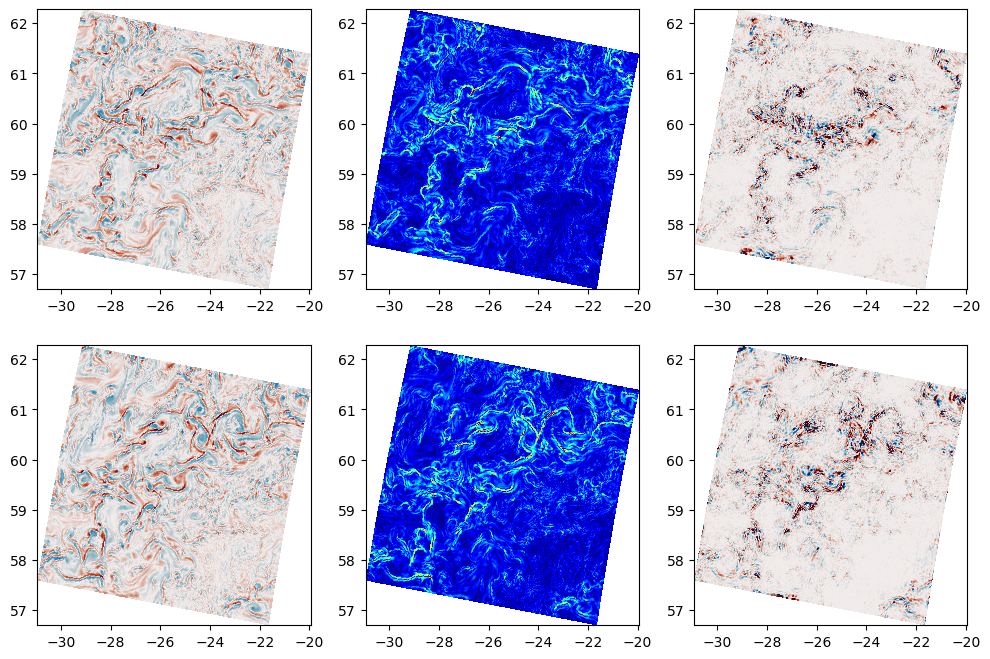

In [6]:
from matplotlib.gridspec import GridSpec
colors={'#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf'}
from cmocean import cm

fig2 = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 3, figure=fig2)
ax2 = [
    [fig2.add_subplot(gs[0, 0]), fig2.add_subplot(gs[0, 1]), fig2.add_subplot(gs[0, 2])],  # First row (3 columns)
    [fig2.add_subplot(gs[1, 0]), fig2.add_subplot(gs[1, 1]), fig2.add_subplot(gs[1, 2])]
]

ax2[0][0].pcolormesh(lonr,latr,Row[tin,:,:],cmap=cm.balance,vmin=-1.5,vmax=1.5)
ax2[0][1].pcolormesh(lonr,latr,strainofw[tin,:,:],cmap='jet',vmin=0,vmax=1.5)
ax2[0][2].pcolormesh(lonr,latr,Th4_w[tin,:,:],cmap=cm.balance,vmin=-5e-7,vmax=5e-7)


ax2[1][0].pcolormesh(lonr,latr,Ronw[tin,:,:],cmap=cm.balance,vmin=-1.5,vmax=1.5)
ax2[1][1].pcolormesh(lonr,latr,strainofnw[tin,:,:],cmap='jet',vmin=0,vmax=1.5)
ax2[1][2].pcolormesh(lonr,latr,Th4_nw[tin,:,:],cmap=cm.balance,vmin=-5e-7,vmax=5e-7)


In [ ]:
vort_band = np.linspace(-5, 5, 500)
strain_band = np.linspace(0.5e-3, 5, 500)

jpdfw, x_edges, y_edges,jpdf_distw,weighted_divw=get_jpdf_ca(vort_band,strain_band,Row,strainofw,Th4_w)
jpdfnw, x_edges, y_edges,jpdf_distnw,weighted_divnw=get_jpdf_ca(vort_band,strain_band,Ronw,strainofnw,Th4_nw)



In [ ]:
xx_c = (x_edges[:-1] + x_edges[1:]) / 2  
yy_c = (y_edges[:-1] + y_edges[1:]) / 2  
vortbin,strainbin=np.meshgrid(xx_c,yy_c)

<>:38: SyntaxWarning: invalid escape sequence '\P'
<>:60: SyntaxWarning: invalid escape sequence '\P'
<>:38: SyntaxWarning: invalid escape sequence '\P'
<>:60: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_4138529/188636128.py:38: SyntaxWarning: invalid escape sequence '\P'
  colorbar1.ax.set_title('$\Pi_{4}$', fontsize=12, pad=-25)
/tmp/ipykernel_4138529/188636128.py:60: SyntaxWarning: invalid escape sequence '\P'
  colorbar1.ax.set_title('$\Pi_{4}$', fontsize=12, pad=-25)
/tmp/ipykernel_4138529/188636128.py:36: RuntimeWarning: invalid value encountered in divide
  cs2=ax2[0][1].pcolormesh(vortbin,strainbin, (weighted_divw/jpdf_distw*filter01).T,cmap=cbar1,norm=norm1)
/tmp/ipykernel_4138529/188636128.py:58: RuntimeWarning: invalid value encountered in divide
  cs2=ax2[1][1].pcolormesh(vortbin,strainbin, (weighted_divnw/jpdf_distnw*filter01).T,cmap=cbar1,norm=norm1)


(0.0, 5.0)

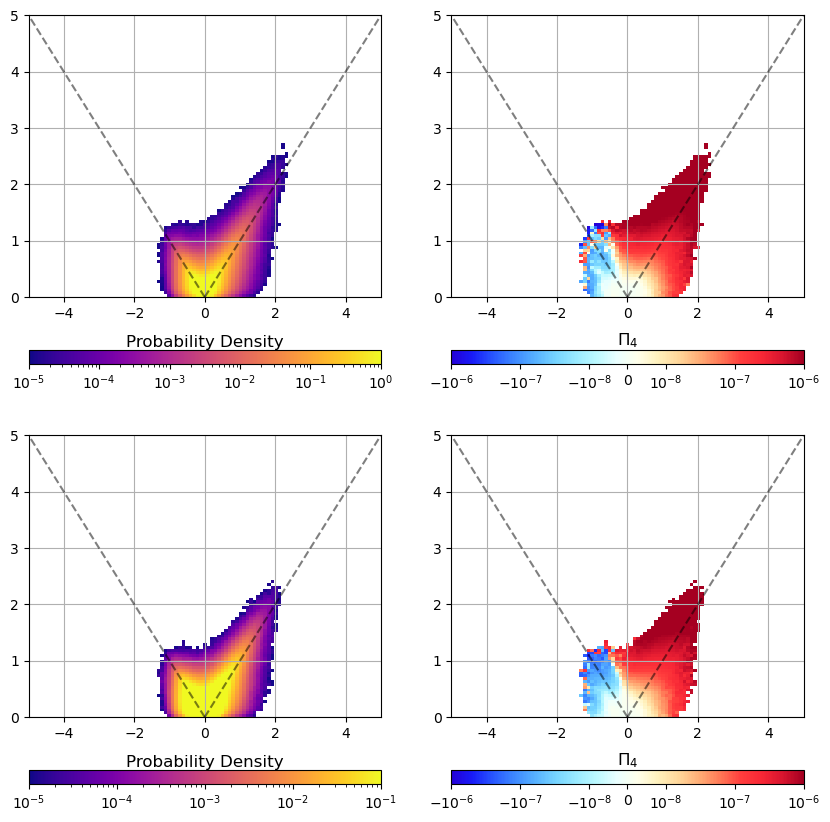

In [27]:
from matplotlib.gridspec import GridSpec
colors={'#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf'}
from cmocean import cm
import matplotlib.colors as mcolors  # 正确导入颜色模块
from matplotlib.colors import SymLogNorm
linthresh = 1e-8  #
linscale = 0.5     #
vmin = -1e-6       # 
vmax = 1e-6        # 
norm1 = SymLogNorm(linthresh=linthresh, linscale=linscale, vmin=vmin, vmax=vmax)
os.chdir('/meddy/simingzhang/Analysis/python/python3/Load_NCL_colorbar')
from matplotlib.colors import LinearSegmentedColormap
from NCL_colorbar import loadcolorbar
cbar1=loadcolorbar("BlueDarkRed18")

fig2 = plt.figure(figsize=(10, 10))
gs = GridSpec(2, 2, figure=fig2)
ax2 = [
    [fig2.add_subplot(gs[0, 0]), fig2.add_subplot(gs[0, 1])],  # First row (3 columns)
    [fig2.add_subplot(gs[1, 0]), fig2.add_subplot(gs[1, 1])]
]

filter01 = np.where(jpdfw>1e-5, 1, np.nan)
cs2=ax2[0][0].pcolormesh(vortbin,strainbin, (jpdfw*filter01).T,cmap='plasma',norm=mcolors.LogNorm(vmin=1e-5, vmax=1e-1))
colorbar1 = fig2.colorbar(cs2, ax=ax2[0][0], orientation='horizontal', pad=0.15, fraction=0.045, aspect=25)
colorbar1.ax.set_title('Probability Density', fontsize=12, pad=-25)

ax2[0][0].plot(np.linspace(0, -5, 10), np.linspace(0, 5, 10), 'k--', alpha=0.5)
ax2[0][0].plot(np.linspace(0, 5), np.linspace(0, 5), 'k--', alpha=0.5)
ax2[0][0].grid(True)
ax2[0][0].set_xlim([-5,5])
ax2[0][0].set_ylim([0,5])



cs2=ax2[0][1].pcolormesh(vortbin,strainbin, (weighted_divw/jpdf_distw*filter01).T,cmap=cbar1,norm=norm1)
colorbar1 = fig2.colorbar(cs2, ax=ax2[0][1], orientation='horizontal', pad=0.15, fraction=0.045, aspect=25)
colorbar1.ax.set_title('$\Pi_{4}$', fontsize=12, pad=-25)
ax2[0][1].plot(np.linspace(0, -5, 10), np.linspace(0, 5, 10), 'k--', alpha=0.5)
ax2[0][1].plot(np.linspace(0, 5), np.linspace(0, 5), 'k--', alpha=0.5)
ax2[0][1].grid(True)
ax2[0][1].set_xlim([-5,5])
ax2[0][1].set_ylim([0,5])


filter01 = np.where(jpdfnw>1e-5, 1, np.nan)
cs2=ax2[1][0].pcolormesh(vortbin,strainbin, (jpdfnw*filter01).T,cmap='plasma',norm=mcolors.LogNorm(vmin=1e-5, vmax=1e-1))
colorbar1 = fig2.colorbar(cs2, ax=ax2[1][0], orientation='horizontal', pad=0.15, fraction=0.045, aspect=25)
colorbar1.ax.set_title('Probability Density', fontsize=12, pad=-25)

ax2[1][0].plot(np.linspace(0, -5, 10), np.linspace(0, 5, 10), 'k--', alpha=0.5)
ax2[1][0].plot(np.linspace(0, 5), np.linspace(0, 5), 'k--', alpha=0.5)
ax2[1][0].grid(True)
ax2[1][0].set_xlim([-5,5])
ax2[1][0].set_ylim([0,5])


cs2=ax2[1][1].pcolormesh(vortbin,strainbin, (weighted_divnw/jpdf_distnw*filter01).T,cmap=cbar1,norm=norm1)
colorbar1 = fig2.colorbar(cs2, ax=ax2[1][1], orientation='horizontal', pad=0.15, fraction=0.045, aspect=25)
colorbar1.ax.set_title('$\Pi_{4}$', fontsize=12, pad=-25)
ax2[1][1].plot(np.linspace(0, -5, 10), np.linspace(0, 5, 10), 'k--', alpha=0.5)
ax2[1][1].plot(np.linspace(0, 5), np.linspace(0, 5), 'k--', alpha=0.5)
ax2[1][1].grid(True)
ax2[1][1].set_xlim([-5,5])
ax2[1][1].set_ylim([0,5])

In [ ]:
jpdf.shape